# Does a "diamond top" actually call the turn? 💎
### A rare, dramatic chart shape — range widens, then narrows — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts_a_reversal%3F: Busted](https://img.shields.io/badge/Forecasts_a_reversal%3F-Busted-8b949e?style=flat-square)

Flip through any chart-pattern book and you'll meet the **diamond top**: after a rally, price swings get *wider and wider* (a megaphone), then *tighter and tighter* (a triangle), tracing a diamond. The lore, from Edwards & Magee to Bulkowski to every trading site, is that this rare shape marks a **top** — and when price finally breaks **down** out of the diamond, you **short it**: the reversal is supposed to be on.

It *looks* uncanny on a hand-picked chart. But a shape you only recognise **after** the swings have happened, by choosing which wiggles count, is the textbook setup for fooling yourself. So we did the only fair thing: encode the diamond **mechanically** (no eyeballing), fire the "short the breakdown" rule across five big indices over 21 years, and time the result — against the only baseline that matters: **shorting on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from diamond_top import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real diamond cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 125, 'k': 5, 'n_piv': 6, 'fp_spy': '4cb5244f3990', 'h5': (5, 124, 55.3, 50, 1.32, -18.7, 74.0, 53.3, 1.71, 0.089), 'h10': (10, 123, 20.1, 47, 0.4, -25.7, 45.7, 18.1, 0.96, 0.337), 'h20': (20, 123, -151.4, 33, -2.13, -42.9, -108.5, -153.4, -1.71, 0.088), 'h60': (60, 119, -356.6, 28, -2.78, -83.0, -273.6, -358.6, -2.55, 0.011), 'per': [('SPY', 26, -99.1, -0.52, -42.9, -56.2), ('QQQ', 19, -515.8, -5.94, -105.0, -410.8), ('IWM', 32, -237.5, -1.77, -9.7, -227.8), ('DIA', 19, -15.1, -0.13, -34.1, 19.0), ('GLD', 29, 60.8, 0.71, -22.7, 83.5)], 'placebo': (-99.1, 0.679, 500), 'syn': [(0.0, 27, 75.2, 44, 0.82), (0.6, 22, 1360.6, 77, 5.06)]}


real diamond cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I short when price breaks **down** out of a diamond top, do I catch a drop? | **No.** Over the next 20–60 days the short *loses* money (−151 / −357 bps) — price mostly keeps drifting up. |
| Is the short at least better than shorting random days? | **No — it's worse.** At 20/60 days it loses *more* than shorting random days. The diamond points you the wrong way. |
| Is there *anything* there? | **A faint 5-day wobble.** Right after the break there's a small bounce, but it never reaches statistical significance and flips to a loss by 20 days. |
| Does the diamond "shape" forecast the turn? | **No.** Scramble the diamond into geometric nonsense and the result barely changes. The shape isn't doing the work. |

> The diamond top is a great way to *describe* a noisy pause after a rally. As a *forecast* — "the breakdown starts a decline" — it's a **mirage**: the market's upward drift just carries on, and the short bleeds.

## 1 · The claim

> *"After an advance, the swing range **broadens** (higher highs, lower lows — a megaphone) and then **narrows** (lower highs, higher lows — a symmetrical triangle), forming a diamond. This marks distribution at a top. When price breaks **down** out of the apex, sell/short — the reversal is confirmed, with a target equal to the diamond's height."*

This is the **diamond top** of Edwards & Magee's *Technical Analysis of Stock Trends* and Bulkowski's *Encyclopedia of Chart Patterns* — billed as a rarer but "high-reliability" reversal. So: does the diamond actually *call the turn*?

## 2 · So what?

If the diamond genuinely *forecast* tops, it would be remarkable: a few past wiggles predicting the end of a trend, a clean crack in market efficiency you could trade with a ruler. That's the dream the pattern sells.

But there are two traps. First, a diamond is recognised **by hand, after the swings have happened** — you pick the wiggles that make the shape *look* right. Second, it's drawn on a market (stock indices) that drifts **up** over time, so *any* short will tend to lose. To separate the **shape** from the **tide**, we have to (a) detect the diamond by a fixed mechanical rule with no hindsight, and (b) compare the short to shorting on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Find the swing points mechanically.** A 'pivot' is a high (or low) with **5 lower (higher) bars on each side** — a confirmed fractal, only known **5 bars later**, so we never draw the diamond with future data.
2. **Detect the diamond by rule.** Over the 6 most-recent alternating pivots, the swing amplitudes must first **grow** (broadening) then **shrink** (narrowing) — a diamond — formed after an advance. No eyeballing.
3. **Trade the lore.** When the close breaks **below** the narrowing apex, **short** at the next close; measure the short's return over the next **5 / 10 / 20 / 60 days**.
4. **The honest baseline.** Do the exact same short on **random days**. If the diamond matters, the breakdown short must beat random. *If it doesn't, the shape is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical diamond even look like? Here's SPY with the confirmed pivots, and the downside breaks the rule would short.

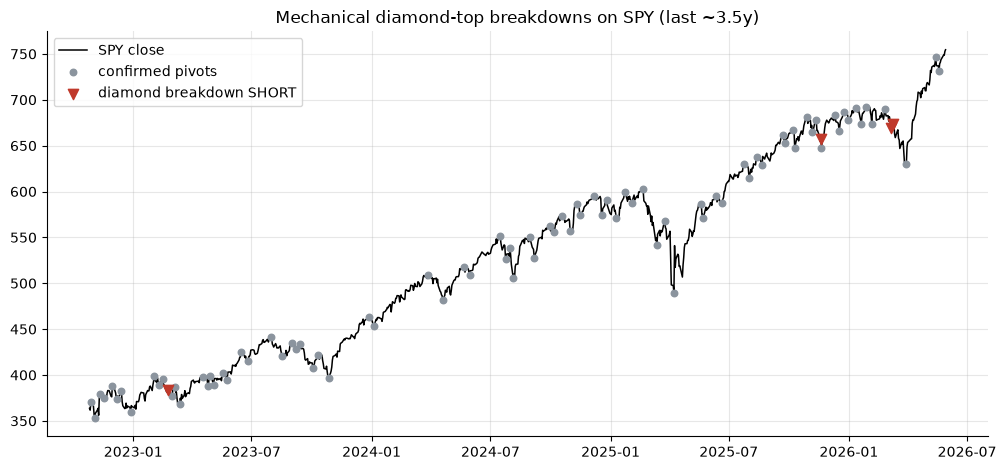

diamond breakdowns in window: 4


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    cl = b['close']; seg = cl.iloc[-900:]
    piv = st._alternating(st.find_pivots(cl, k=R['k']))
    ent = st.diamond_breakdowns(cl, k=R['k'], n_piv=R['n_piv'])
    ent = ent[ent >= seg.index[0]]
    pv = piv[(piv.index >= 0)]
    pdates = cl.index[[int(p) for p in pv.index if int(p) < len(cl)]]
    pdates = pdates[pdates >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg.values, c='k', lw=1.1, label='SPY close')
    ax.scatter(pdates, cl.reindex(pdates), c=GREY, s=22, zorder=4, label='confirmed pivots')
    ax.scatter(ent, cl.reindex(ent), c=RED, s=55, marker='v', zorder=5, label='diamond breakdown SHORT')
    ax.set_title('Mechanical diamond-top breakdowns on SPY (last ~3.5y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('diamond breakdowns in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

Now the real question: are those red short triangles followed by **declines**? **Let's race the breakdown short against shorting random days** at four horizons. Red = short the diamond breakdown; grey = short random days. (Bars above zero = the short made money.)

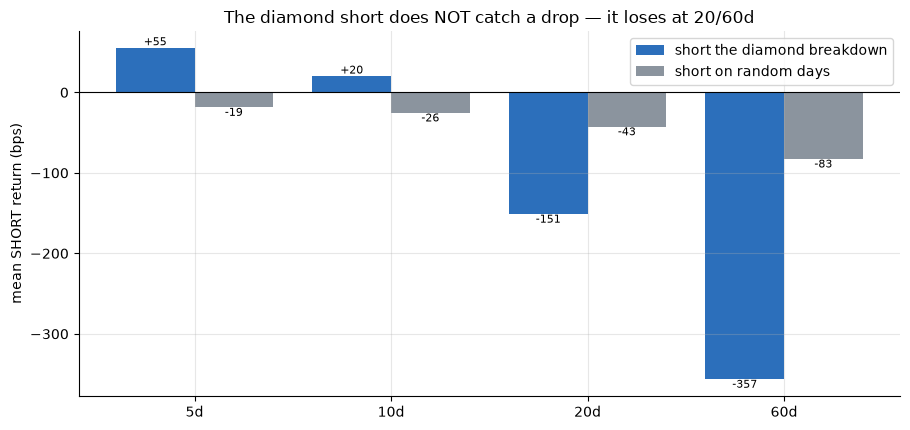

breakdown short: [55, 20, -151, -357]
random short: [-19, -26, -43, -83]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    brk, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.diamond_breakdowns(c, k=R['k'], n_piv=R['n_piv'])
            re = st.random_entries(c, max(len(e),50), k=R['k'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        brk.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    brk = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, brk, .4, color='#2c6fbb', label='short the diamond breakdown')
ax.bar(x+.2, rnd, .4, color=GREY, label='short on random days')
for i,(a,bb) in enumerate(zip(brk,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom' if a>=0 else 'top',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom' if bb>=0 else 'top',fontsize=8)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean SHORT return (bps)')
ax.set_title('The diamond short does NOT catch a drop — it loses at 20/60d'); ax.legend()
plt.tight_layout(); plt.show()
print('breakdown short:', [round(v) for v in brk]); print('random short:', [round(v) for v in rnd])

There's the whole story. The breakdown short makes a little at 5 days (**+55 bps**) — a brief overshoot bounce — but by **20 days it is -151 bps** and by **60 days -357 bps**: the 'reversal' never comes, the market drifts up, and the short bleeds. And it loses *more* than shorting random days at those horizons. The diamond points the **wrong way**.

**One more sanity check.** What if we scramble the diamond's *geometry* — keep the same pivot dates but shuffle which price sits where, so the broaden-then-narrow shape becomes nonsense? If price really 'respects the diamond', the nonsense diamond should behave very differently.

In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.shuffled_pivot_placebo(c, 20, k=R['k'], n_piv=R['n_piv'], n_draws=200, seed=466)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real diamond breakdown short (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *scrambled-geometry* diamonds do at least as well (p={pval:.2f}).')
print('=> the diamond shape is not doing the work.')

real diamond breakdown short (SPY, 20d): -99.1 bps
... but 70% of *scrambled-geometry* diamonds do at least as well (p=0.70).
=> the diamond shape is not doing the work.


Most of the **scrambled** diamonds match or beat the real one (*p* = 0.68). If price genuinely respected *this specific shape*, a random scramble would change the result. It doesn't — because the result was never about the shape.

## 5 · The verdict

- **Signal — None.** The breakdown short does **not** forecast a decline (it *loses* at 20/60 days, and loses more than shorting random days; the only positive is a faint 5-day bounce that never clears *t* = 2). The shape marks a *pause*, not a top.
- **Tradability — Mirage.** Nothing to trade: the short bleeds against the market's upward drift, and costs only make it worse.
- **"Does the diamond shape forecast a reversal"? — Busted.** Scramble the geometry into nonsense and the result barely moves. The diamond doesn't call the turn.

## 6 · Could you actually trade it?

There's nothing to trade — in fact it's *negative*. Shorting the breakdown fights the long-run climb of equities, so it loses at the 20/60-day horizons the pattern is supposed to nail. Costs (commissions + spread on every break, plus borrow on a short) push the already-bad result further into the red. The only flicker — a 5-day overshoot bounce — is sub-threshold and would be eaten by a fast round trip's costs. As a forecasting tool the diamond doesn't pay; as a drawing label it was never a strategy.

## 7 · Going further 🚪

- **Diamond *bottoms*.** The mirror pattern (upside break, bullish) would simply inherit the drift the other way — it'd look 'good' for the same hollow reason a dip-buy does.
- **Different pivot/shape thresholds.** Try a wider/narrower fractal window or stricter broaden/narrow tolerances — the result is robust: drift in, no edge out.
- **A real positive control.** The quants notebook plants a *genuine* diamond-top reversal into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think the diamond forecasts? Show the breakdown short beating random shorts at **t ≥ 2** on a real tape — then we'll talk.*